# Modeling (Mia Arnold)

Using Nutrition Information to Classify Brand Tier (Premium Foods)

Mia Arnold - Jordan Blackman - Allen Ros

Shirley Marcos School of Engineering, University of San Diego

ADS-502 Applied Data Mining

# Goals

1. Data type transformation, remove features that would lead to overfitting, test train split, SMOTENC(nominal and continuous), Encoding, and Scaling.

2. Establish Baseline Model and evaluation metrics

3. Train initial models, tune hyperparameters (max leaf, minobservations, C for regularization), explore cost matrices, and explore bagging and boosting

4. Compare all models across multiple metrics beyond accuracy

Models to explore: Baseline (Majority Class), Naive Bayes, Decision Tree (CART, C5.0), kNN Classifier, Logistic Regression, SVC (Linear), SVC (RBF), SVC (Polynamial), SVC (Sigmoid), Random Forest Classifier (with bagging and boosting), XGBoost, Adaboost, and Neural Network.

# Data Type Transformation and Removing Overfitting Features

In [1]:
# import the necessary packages
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv("C:/Users/princ/OneDrive/Desktop/GitHub/ads502-final-project/food_menu_nutrition_dataset.csv")

# log price, protein, and sugars to handle significant skew
df['log_price_usd_normalized'] = np.log1p(df['price_usd_normalized'])
df['log_protein_g'] = np.log1p(df['protein_g'])
df['log_sugars_g'] = np.log1p(df['sugars_g'])

# square root serving size, calories, fat, carbs, sodium to handle small skew
df['sqrt_serving_size_g'] = np.sqrt(df['serving_size_g'])
df['sqrt_calories'] = np.sqrt(df['calories'])
df['sqrt_total_fat_g'] = np.sqrt(df['total_fat_g'])
df['sqrt_total_carbs_g'] = np.sqrt(df['total_carbs_g'])
df['sqrt_sodium_mg'] = np.sqrt(df['sodium_mg'])

# flip average rating to handle left skew, units are flipped
reflect_constant = df['avg_rating'].max() + 1
df['trans_avg_rating'] = np.sqrt(reflect_constant - df['avg_rating'])

# is_bestseller is the only numerical variable left alone

# drop all original columns that were transformed
df = df.drop(columns=['price_usd_normalized', 'protein_g', 'sugars_g',
                      'serving_size_g', 'calories', 'total_fat_g',
                      'total_carbs_g', 'sodium_mg', 'avg_rating'])

# set up items that are nto being used for training models
items_to_drop = ['item_name', 'city', 'brand_name',
                 'brand_tier']

# get dependent and independent variables
Y = (df['brand_tier'] == 'premium').astype(int)
X = df.drop(columns=items_to_drop)

# view the data
df.head().T

,0,1,2,3,4
item_name,Veggie Sub,Waffles with Syrup,Grilled Chicken Salad,Waffles with Syrup,Chocolate Brownie
item_category,Sandwich,Dessert,Salad,Dessert,Dessert
item_subcategory,Veg,Veg,Non-Veg,Veg,Veg
brand_name,Five Guys,KFC,Domino's,Five Guys,Subway
brand_tier,mid,budget,budget,mid,budget
country,UK,USA,Canada,USA,USA
city,London,Austin,Toronto,Chicago,Chicago
city_tier,metro,tier-2,metro,metro,metro
is_bestseller,0,0,0,0,0
log_price_usd_normalized,2.267994,1.329724,1.912501,2.248129,1.332366


# Test Train Split

In [2]:
# test train split with random state and stratification
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y)

# SMOTE

In [3]:
# Oversample the minority class (Premium)
from imblearn.over_sampling import SMOTENC

cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.drop(
    items_to_drop, errors='ignore').tolist()

cat_indices = [X_train.columns.get_loc(col) for col in cat_cols]

print("Before SMOTE")
print(Y_train.value_counts())

smote_nc = SMOTENC(categorical_features=cat_indices, random_state=42)
X_train, Y_train = smote_nc.fit_resample(X_train, Y_train)

print("After SMOTE:")
print(Y_train.value_counts())

Before SMOTE
brand_tier
0    5404
1     596
Name: count, dtype: int64
After SMOTE:
brand_tier
0    5404
1    5404
Name: count, dtype: int64


# Encoding

In [4]:
# encode variables
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# align encoded variables
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns, fill_value=0)

# Scaling

In [5]:
from sklearn.preprocessing import StandardScaler

# scale variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# Establish Evaluation Function

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# define a reusable function to calculate evaluation metrics for all models


def evaluate_model(y_true, y_pred, y_prob=None, model_name="Model", verbose=True):

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    roc_auc = None
    if y_prob is not None:
        roc_auc = roc_auc_score(y_true, y_prob)

    if verbose:
        print(f"--- {model_name} Evaluation ---")
        print(f"Accuracy:    {acc:.4f}")
        print(f"Precision:   {prec:.4f}")
        print(f"Recall:      {rec:.4f} (Sensitivity)")
        print(f"Specificity: {specificity:.4f}")
        print(f"F1-Score:    {f1:.4f}")

        if roc_auc is not None:
            print(f"ROC AUC:     {roc_auc:.4f}")

        print("-" * 30 + "\n")

        fig, ax = plt.subplots(figsize=(4, 4))
        ConfusionMatrixDisplay.from_predictions(
            y_true, y_pred, ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f"Confusion Matrix: {model_name}")
        plt.tight_layout()
        plt.show()

    return {
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "specificity": specificity,
        "f1_score": f1,
        "roc_auc": roc_auc
    }

# Establish Reusable Modeling Function

In [7]:
# establish a function trains and evaluates all models
def train_and_evaluate(model, x_train, y_train, x_test, y_test, model_name, verbose=True):

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    y_prob = None
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(x_test)[:, 1]

    metrics = evaluate_model(y_test, y_pred, y_prob, model_name, verbose)

    return metrics

# Establish Baseline Model

--- Baseline (Majority Class) Evaluation ---
Accuracy:    0.9007
Precision:   0.0000
Recall:      0.0000 (Sensitivity)
Specificity: 1.0000
F1-Score:    0.0000
ROC AUC:     0.5000
------------------------------



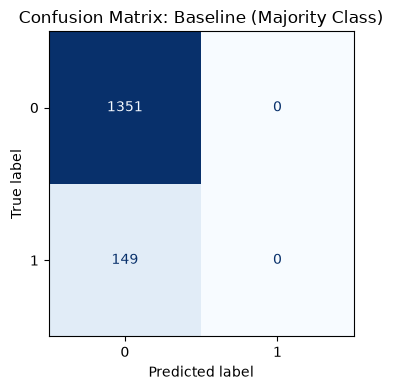

In [8]:
# dummy model always predicts the majority class
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="constant", constant=0)

baseline_metrics = train_and_evaluate(
    baseline,
    X_train,
    Y_train,
    X_test,
    Y_test,
    model_name="Baseline (Majority Class)"
)

# Train Initial Models

--- Naive Bayes 2 Evaluation ---
Accuracy:    0.8480
Precision:   0.3792
Recall:      0.8322 (Sensitivity)
Specificity: 0.8497
F1-Score:    0.5210
ROC AUC:     0.8633
------------------------------



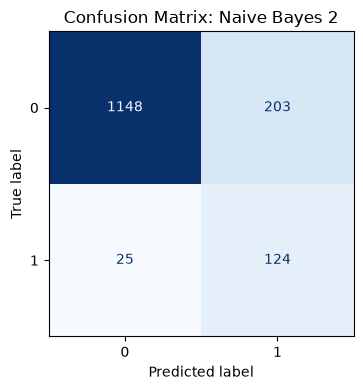

In [17]:
# Naive Bayes (Bernoulli)

from sklearn.naive_bayes import BernoulliNB

nb_2 = BernoulliNB()

nb_2_metrics = train_and_evaluate(
    nb_2,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="Naive Bayes 2"
)

--- CART Evaluation ---
Accuracy:    0.9287
Precision:   0.6000
Recall:      0.8456 (Sensitivity)
Specificity: 0.9378
F1-Score:    0.7019
ROC AUC:     0.8917
------------------------------



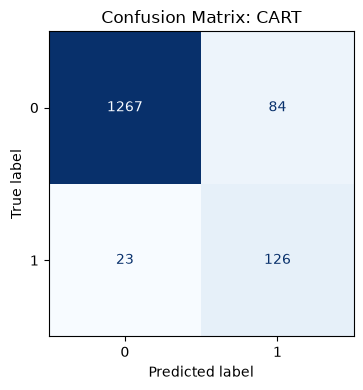

In [9]:
# Descision Tree (CART)
from sklearn.tree import DecisionTreeClassifier

classWeights = {0: 1.0, 1: 5.0}
cart01 = DecisionTreeClassifier(random_state = 42, criterion = "gini", class_weight = classWeights)

cart01_metrics = train_and_evaluate(
    cart01,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="CART"
)

--- C5.0 Evaluation ---
Accuracy:    0.9313
Precision:   0.6075
Recall:      0.8725 (Sensitivity)
Specificity: 0.9378
F1-Score:    0.7163
ROC AUC:     0.9052
------------------------------



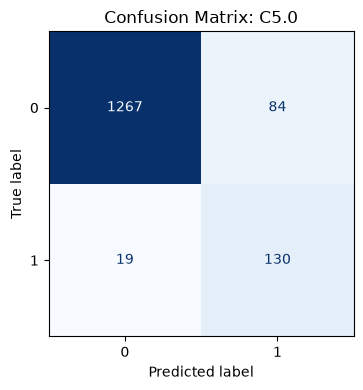

In [10]:
# Descision Tree (C5.0)
from sklearn.tree import DecisionTreeClassifier

classWeights = {0: 1.0, 1: 5.0}
c50_2 = DecisionTreeClassifier(random_state = 42, criterion = "entropy", class_weight = classWeights)

c50_2_metrics = train_and_evaluate(
    c50_2,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="C5.0"
)

C:\Users\princ\.conda\envs\ADS502\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


--- KNN (n=4) Evaluation ---
Accuracy:    0.8373
Precision:   0.3234
Recall:      0.5839 (Sensitivity)
Specificity: 0.8653
F1-Score:    0.4163
ROC AUC:     0.8067
------------------------------



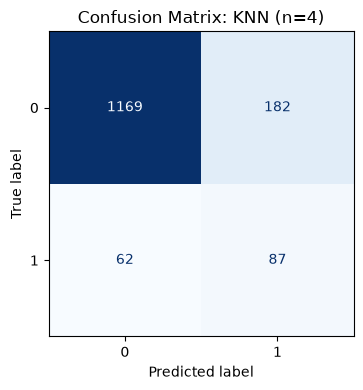

In [11]:
#kNN Classifier (n=4, weighted distance)

from sklearn.neighbors import KNeighborsClassifier

knn_2 = KNeighborsClassifier(n_neighbors=4, weights = 'distance')

knn_2_metrics = train_and_evaluate(
    knn_2,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="KNN (n=4)"
)

C:\Users\princ\.conda\envs\ADS502\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


--- Logistic Regression Evaluation ---
Accuracy:    0.9187
Precision:   0.5529
Recall:      0.9463 (Sensitivity)
Specificity: 0.9156
F1-Score:    0.6980
ROC AUC:     0.9844
------------------------------



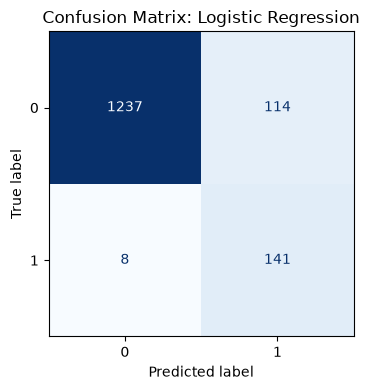

In [12]:
# Logisitic Regression

from sklearn.linear_model import LogisticRegression

log_reg_2 = LogisticRegression(random_state=42, penalty = None)

log_reg_2_metrics = train_and_evaluate(
    log_reg_2,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="Logistic Regression"

)

--- Neural Network Evaluation ---
Accuracy:    0.9407
Precision:   0.6546
Recall:      0.8523 (Sensitivity)
Specificity: 0.9504
F1-Score:    0.7405
ROC AUC:     0.9755
------------------------------



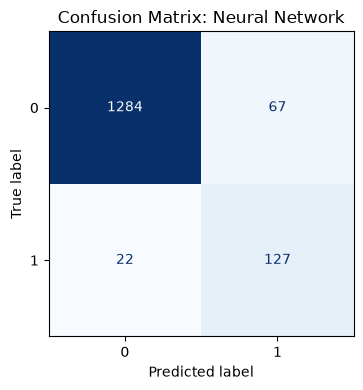

In [14]:
# Neural Networks

from sklearn.neural_network import MLPClassifier

mlp_2_model = MLPClassifier(
    activation='relu',
    solver='adam',
    alpha=0.05,
    max_iter=1000,
    early_stopping=False,
    random_state=42
)

mlp_2_metrics = train_and_evaluate(
    mlp_2_model,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="Neural Network"
)

--- Random Forest Evaluation ---
Accuracy:    0.9467
Precision:   0.6865
Recall:      0.8523 (Sensitivity)
Specificity: 0.9571
F1-Score:    0.7605
ROC AUC:     0.9745
------------------------------



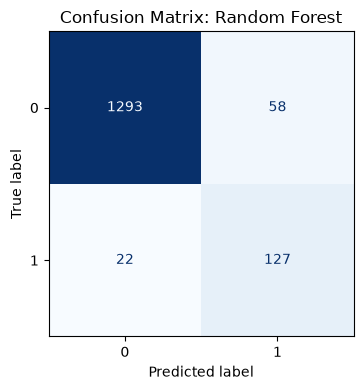

In [15]:
# Balanced Random Forest Classifier

from imblearn.ensemble import BalancedRandomForestClassifier

random_forest = BalancedRandomForestClassifier(n_estimators = 500, random_state=42)

random_forest_metrics = train_and_evaluate(
    random_forest,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="Random Forest"
)

# Compare Initial Models

In [18]:
# Compare all model results
model_results = [val for name, val in globals().items(
) if 'metrics' in name and isinstance(val, dict)]

# 2. Convert to DataFrame
results_df = pd.DataFrame(model_results)

# 3. Set the 'model' column as the index for better readability
results_df.set_index('model', inplace=True)

# 4. Display the table
results_df.sort_values(by='roc_auc', ascending=False). round(2)

,accuracy,precision,recall,specificity,f1_score,roc_auc
model,,,,,,
Logistic Regression,0.92,0.55,0.95,0.92,0.70,0.98
Neural Network,0.94,0.65,0.85,0.95,0.74,0.98
Random Forest,0.95,0.69,0.85,0.96,0.76,0.97
C5.0,0.93,0.61,0.87,0.94,0.72,0.91
CART,0.93,0.60,0.85,0.94,0.70,0.89
Naive Bayes 2,0.85,0.38,0.83,0.85,0.52,0.86
KNN (n=4),0.84,0.32,0.58,0.87,0.42,0.81
Baseline (Majority Class),0.90,0.00,0.00,1.00,0.00,0.50
